# 自然语言处理领域 - 垃圾短信识别

# 1.实验介绍

## 1.1 实验背景
垃圾短信 (Spam Messages，SM) 是指未经过用户同意向用户发送不愿接收的商业广告或者不符合法律规范的短信。    
随着手机的普及，垃圾短信在日常生活日益泛滥，已经严重的影响到了人们的正常生活娱乐，乃至社会的稳定。     
据 360 公司 2020 年第一季度有关手机安全的报告提到，360 手机卫士在第一季度共拦截各类垃圾短信约 34.4 亿条，平均每日拦截垃圾短信约 3784.7 万条。      
大数据时代的到来使得大量个人信息数据得以沉淀和积累，但是庞大的数据量缺乏有效的整理规范；   
在面对量级如此巨大的短信数据时，为了保证更良好的用户体验，如何从数据中挖掘出更多有意义的信息为人们免受垃圾短信骚扰成为当前亟待解决的问题。

## 1.2 实验要求
1) 任务提供包括数据读取、基础模型、模型训练等基本代码  
2) 参赛选手需完成核心模型构建代码，并尽可能将模型调到最佳状态  
3) 模型单次推理时间不超过 ** 10 秒  **

## 1.3 实验环境 
可以使用基于 Python 的 Pandas、Numpy、Sklearn 等库进行相关特征处理，使用 Sklearn 框架训练分类器，也可编写深度学习模型，使用过程中请注意 Python 包（库）的版本。

## 1.4 注意事项
+ Python 与 Python Package 的使用方式，可在右侧 `API文档` 中查阅。
+ 当右上角的『Python 3』长时间指示为运行中的时候，造成代码无法执行时，可以重新启动 Kernel 解决（左上角『Kernel』-『Restart Kernel』）。

## 1.5 参考资料
- Numpy：https://www.numpy.org/
- Pandas: https://pandas.pydata.org/
- Sklearn: https://scikit-learn.org/
- jieba: https://github.com/fxsjy/jieba
- 四川大学机器智能实验室停用词库：https://github.com/goto456/stopwords/blob/master/scu_stopwords.txt

# 2.实验内容

## 2.1 数据集
- 该数据集包括了约 7.87 万条数据，有 3 个字段 label、 message 和 msg_new， 分别代表了短信的类别、短信的内容和分词后的短信
- 中文分词工具 [jieba](https://github.com/fxsjy/jieba)
- 0 代表正常的短信，1 代表恶意的短信
- 正常短信和恶意短信举例：

|label|message（短信内容）|msg_new（短信分词后）|
|--|--|--|
|0|人们经常是失去了才发现它的珍贵|人们 经常 是 失去 了 才 发现 它 的 珍贵|
|1|本人现在承办驾驶证业务!招收学员，一对 一教学|本人 现在 承办 驾驶证 业务 ! 招收 学员 ， 一对   一 教学|

In [2]:
# 导入相关的包
import warnings

import os
import pandas as pd
import numpy as np

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
warnings.filterwarnings('ignore')

In [2]:
# 数据集的路径
data_path = "./datasets/5f9ae242cae5285cd734b91e-momodel/sms_pub.csv"
# 读取数据
sms = pd.read_csv(data_path, encoding='utf-8')
# 显示前 5 条数据
sms.head()
type(sms.msg_new)

pandas.core.series.Series

In [ ]:
# 显示数据集的一些信息
sms.groupby('label').describe()


message                                                                  \
        count  unique                                                top freq   
label                                                                           
0      707464  707464                      商业秘密的秘密性那是维系其商业价值和垄断地位的前提条件之一    1   
1       79146   79146  南口阿玛施新春第一批限量春装到店啦         春暖花开淑女裙、冰蓝色公主衫  ...    1   

      msg_new                                                                  
        count  unique                                                top freq  
label                                                                          
0      707464  707464         商业秘密 的 秘密性 那 是 维系 其 商业价值 和 垄断 地位 的 前提条件 之一    1  
1       79146   79146  南口 阿玛施 新春 第一批 限量 春装 到 店 啦                  ...    1

## 2.2 数据处理

### 2.2.1 停用词

停用词是指在信息检索中，为节省存储空间和提高搜索效率，在处理自然语言数据（或文本）之前或之后会自动过滤掉某些字或词，这些字或词即被称为 Stop Words（停用词）。      
这些停用词都是人工输入、非自动化生成的，生成后的停用词会形成一个停用词库。        
本次比赛中采用的是[四川大学机器智能实验室停用词库](https://github.com/goto456/stopwords/blob/master/scu_stopwords.txt)

In [3]:
def read_stopwords(stopwords_path):
    """
    读取停用词库
    :param stopwords_path: 停用词库的路径
    :return: 停用词列表
    """
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        stopwords = f.read()
    stopwords = stopwords.splitlines()
    return stopwords


In [4]:
# 停用词库路径
stopwords_path = r'scu_stopwords.txt'
# 读取停用词
stopwords = read_stopwords(stopwords_path)
# 展示一些停用词
print(stopwords[-20:])


['嘿', '很', '乎', '会', '或', '既', '及', '啦', '了', '们', '你', '您', '哦', '砰', '啊', '你', '我', '他', '她', '它']


### 2.2.2 文本向量化的方法

**1. CountVectorizer**  
目前拥有的数据是长度不统一的文本数据，而绝大多数机器学习算法需要的输入是向量，因此文本类型的数据需要经过处理得到向量。    
我们可以借助 sklearn 中 **CountVectorizer** 来实现文本的向量化，CountVectorizer 实际上是在统计**每个词出现的次数**，这样的模型也叫做**词袋模型**。

In [ ]:
# 假如我们有这样三条短信
simple_train = ['call you tonight', 'Call me a cab', 'Please call me... PLEASE!']

# 导入 CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()

# 从训练数据中学习词汇表
vect.fit(sms.msg_new)

# 查看学习到的词汇表
vect.get_feature_names_out()


array(['00', '000', '0000', ..., '龟鳖', '龟龄', '龟龄集'], dtype=object)

In [ ]:
# 将训练数据向量化，得到一个矩阵
simple_train_dtm = vect.transform(simple_train)
# 由于该矩阵的维度可能十分大，而其中大部分都为 0，所以会采用稀疏矩阵来存储
simple_train_dtm


<3x363469 sparse matrix of type '<class 'numpy.int64'>'
	with 9 stored elements in Compressed Sparse Row format>

In [ ]:
# 将稀疏矩阵转为一般矩阵查看里面的内容
simple_train_dtm.toarray()


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# 结合词汇表和转为得到的矩阵来直观查看内容
pd.DataFrame(simple_train_dtm.toarray(), columns=vect.get_feature_names_out())


,00,000,0000,00000,00000000,00000000000000001,000000000000001,00000051,000025,000029,...,龟背,龟苓,龟苓膏,龟蛇,龟行,龟裂,龟速,龟鳖,龟龄,龟龄集
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**2. TfidfVectorizer**  
与 CountVectorizer 类似的还有 TfidfVectorizer 。        
TF-IDF 算法是创建在这样一个假设之上的：                     
对区别文档最有意义的词语应该是那些在文档中出现频率高的词语，因此选择特征空间坐标系取 TF 词频作为测度，就可以体现同类文本的特点。                                    
另外考虑到单词区别不同类别的能力，TF-IDF 法认为一个单词出现的文本频数越小，它区别不同类别文本的能力就越大。     
因此引入了逆文本频度 IDF 的概念，以 TF 和 IDF 的乘积作为特征空间坐标系的取值测度，并用它完成对权值 TF 的调整，调整权值的目的在于突出重要单词，抑制次要单词。    
在本质上 IDF 是一种试图抑制噪声的加权，并且单纯地认为文本频率小的单词就越重要，文本频率大的单词就越无用。    
 
其中 TF、 IDF 和 TF-IDF 的含义如下：
+ TF：词频。
$$TF(w) = \frac{词 w 在文档中出现的次数}{文档的总词数}$$
+ IDF：逆向文件频率。有些词可能在文本中频繁出现，但并不重要，也即信息量小，如 is, of, that 这些单词，这些单词在语料库中出现的频率也非常大，我们就可以利用这点，降低其权重。
$$IDF(w) = ln \frac{语料库的总文档数}{语料库中词 w 出现的文档数}$$
+ TF-ID 综合参数：TF - IDF = TF * IDF

In [ ]:
# 导入 TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
        token_pattern=r"(?u)\b\w+\b", 
        stop_words=stopwords,
        min_df=2,                 # 忽略低频词
        )
# 在训练数据上拟合并将其转为为 tfidf 的稀疏矩阵形式
simple_train_dtm = tfidf.fit_transform(sms.msg_new)
# 将稀疏矩阵转为一般矩阵
simple_train_dtm.toarray()
# 结合词汇表和转为得到的矩阵来直观查看内容
pd.DataFrame(simple_train_dtm.toarray(), columns=tfidf.get_feature_names_out())


,0,00,000,0000,000025,000050,0001,0004,000410,000428,...,ｑ,ｒ,ｓ,ｔ,ｕ,ｖ,ｗ,ｘ,ｙ,ｚ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
786606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
786607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
786608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 查看词的分布情况

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

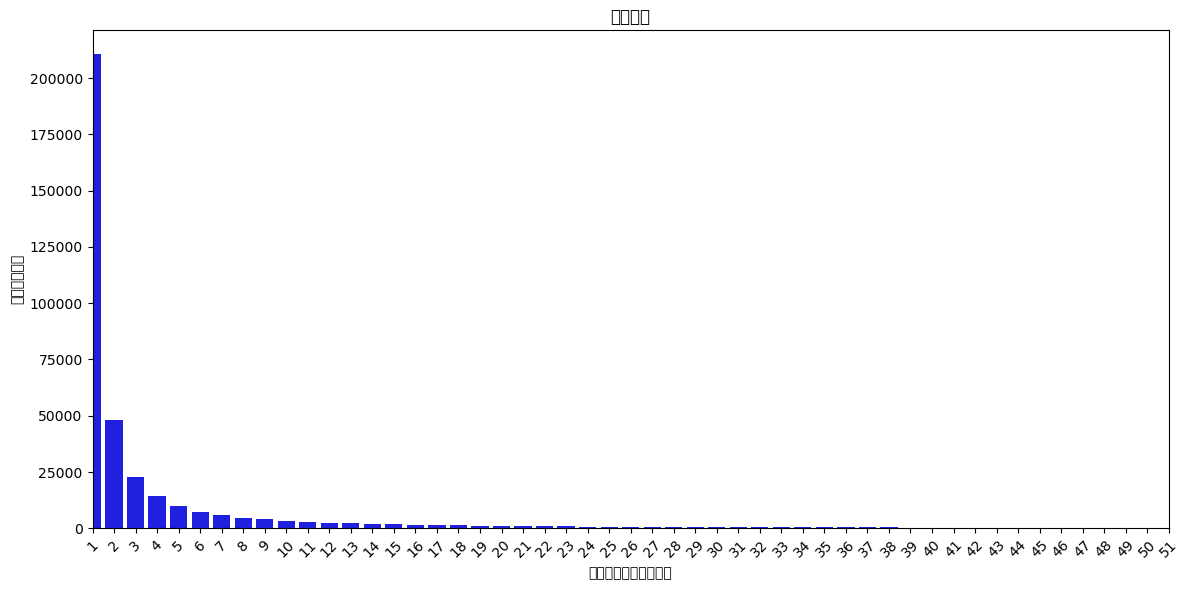

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import pandas as pd
from collections import Counter

# 获取所有词的列表
all_words = []
for message in sms['msg_new']:
    all_words.extend(message.split())

# 统计每个词出现的次数
word_counts = Counter(all_words)

# 统计词频分布：有多少词出现了1次、2次、3次...
frequency_distribution = Counter([count for word, count in word_counts.items()])

# 转换为DataFrame以便绘图
freq_df = pd.DataFrame({
    'word_frequency': list(frequency_distribution.keys()),
    'number_of_words': list(frequency_distribution.values())
}).sort_values('word_frequency')


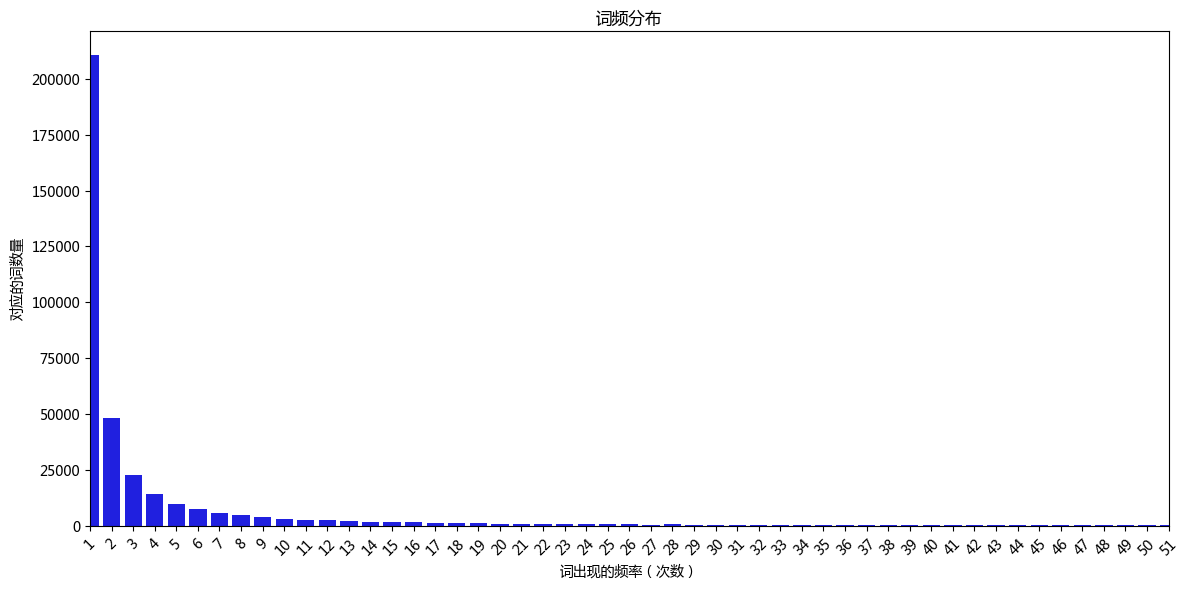

In [29]:

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或者 ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 绘制分布图
plt.figure(figsize=(12, 6))
sns.barplot(x='word_frequency', y='number_of_words', data=freq_df, color='blue')
plt.xlabel('词出现的频率（次数）')
plt.ylabel('对应的词数量')
plt.title('词频分布')
plt.xticks(rotation=45)  # 旋转x轴标签以便更好地显示

# 限制x轴范围，因为高频词很少，可能会使图表很难读
plt.xlim(0, min(50, max(freq_df['word_frequency'])))
plt.tight_layout()
plt.show()

### 2.2.3 划分训练集和测试集

一般的数据集会划分为两个部分：
+ 训练数据：用于训练，构建模型
+ 测试数据：在模型检验时使用，用于评估模型是否有效
<br>

划分比例：
+ 训练集：70% 80% 75%
+ 测试集：30% 20% 25%

<br>

`sklearn.model_selection.train_test_split(x, y, test_size, random_state )`
   +  `x`：数据集的特征值
   +  `y`： 数据集的标签值
   +  `test_size`： 如果是浮点数，表示测试集样本占比；如果是整数，表示测试集样本的数量。
   +  `random_state`： 随机数种子,不同的种子会造成不同的随机采样结果。相同的种子采样结果相同。
   +  `return` 训练集的特征值 `x_train` 测试集的特征值 `x_test` 训练集的目标值 `y_train` 测试集的目标值 `y_test`。

In [3]:
# 构建训练集和测试集
from sklearn.model_selection import train_test_split
X = np.array(sms.msg_new)
y = np.array(sms.label)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.1)
print("总共的数据大小", X.shape)
print("训练集数据大小", X_train.shape)
print("测试集数据大小", X_test.shape)


NameError: name 'sms' is not defined

**注意：** CountVectorizer 默认会去除长度为 1 的字符串，这会丢失一部分信息，通过将 token_pattern 的属性值改为正则表达式 (?u)\b\w+\b 可以解决这个问题。

In [ ]:
# 以 CountVectorizer 为例将数据集向量化
from sklearn.feature_extraction.text import CountVectorizer
# 设置匹配的正则表达式和停用词
vect = CountVectorizer(token_pattern=r"(?u)\b\w+\b", stop_words=stopwords)
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)


## 2.3 模型搭建

朴素贝叶斯是一种基于贝叶斯公式的监督学习算法，并假设每个特征是独立的，该方法在“垃圾邮件分类”、“恶意邮件检测”等领域有着广泛应用。

### 2.3.1 朴素贝叶斯算法的原理

朴素贝叶斯实现分类的原理是基于贝叶斯公式，给定一个样本，计算该样本条件下每个类别的条件概率。  
![image.png](picture/1.png)  
由于假设每个特征是独立的，所以该公式可以化为：    
![image.png](picture/2.png)  
由于分母是确定的，结果只和分子有关。    
![image.png](picture/3.png)  
求出最大的条件概率，其对应的类别就是该样本所属的类别。  
![image.png](picture/4.png)  

### 2.3.2 搭建一个简单的模型

采用 sklearn.naive_bayes 下面的方法，详情请参照：
https://scikit-learn.org/stable/modules/classes.html#module-sklearn.naive_bayes  
MultinomialNB 是一种常用于文本分类的朴素贝叶斯方法，下面以此为例训练一个朴素贝叶斯分类器

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
%time nb.fit(X_train_dtm, y_train)  # 计算训练时间


CPU times: user 192 ms, sys: 40.7 ms, total: 233 ms
Wall time: 239 ms


MultinomialNB()

In [ ]:
# 对测试集的数据集进行预测
y_pred = nb.predict(X_test_dtm)
y_pred


array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
# 在测试集上评估训练的模型
from sklearn import metrics
print("在测试集上的混淆矩阵：")
print(metrics.confusion_matrix(y_test, y_pred))
print("在测试集上的分类结果报告：")
print(metrics.classification_report(y_test, y_pred))
print("在测试集上的 f1-score ：")
print(metrics.f1_score(y_test, y_pred))


在测试集上的混淆矩阵：
[[69594  1220]
 [  136  7711]]
在测试集上的分类结果报告：
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     70814
           1       0.86      0.98      0.92      7847

    accuracy                           0.98     78661
   macro avg       0.93      0.98      0.95     78661
weighted avg       0.98      0.98      0.98     78661

在测试集上的 f1-score ：
0.9191798784122064


### 2.3.3 构建一个 PipeLine

构建 PipleLine 可以将数据处理和数据分类结合在一起，这样输入原始的数据就可以得到分类的结果，方便直接对原始数据进行预测。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

pipeline = Pipeline([
    ('cv', CountVectorizer(token_pattern=r"(?u)\b\w+\b", stop_words=stopwords)),
    ('classifier', MultinomialNB()),
])


In [ ]:
# 可以直接向 Pipeline 中输入文本数据进行训练和预测
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


In [ ]:
# 得到的结果同上面分开的情况是一样的
print("在测试集上的混淆矩阵：")
print(metrics.confusion_matrix(y_test, y_pred))
print("在测试集上的分类结果报告：")
print(metrics.classification_report(y_test, y_pred))
print("在测试集上的 f1-score ：")
print(metrics.f1_score(y_test, y_pred))


在测试集上的混淆矩阵：
[[69594  1220]
 [  136  7711]]
在测试集上的分类结果报告：
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     70814
           1       0.86      0.98      0.92      7847

    accuracy                           0.98     78661
   macro avg       0.93      0.98      0.95     78661
weighted avg       0.98      0.98      0.98     78661

在测试集上的 f1-score ：
0.9191798784122064


# 3.实验题目

**题目内容：** 根据一段中文文本（ 200 个中文字符以内），预测这段文本是否为垃圾短信。 

### 3.1 模型的搭建和训练

可以尝试从以下几个方面去优化模型：
1. 文本向量化可以选择 CountVectorizer 或者 TfidfVectorizer，适当调节里面的参数，如 ngram_range
2. 更换更好的停用词库，请放在 results 目录下
2. 尝试进行数据进行归一化，可以采用 StandardScaler 或者 MaxAbsScaler
3. 适当调节分类器的参数，提高模型的表现

注意：

1. 你可以在我们准好的接口中实现的朴素贝叶斯模型（若使用可以修改除predict外的函数接口），也可以自己训练其他模型，但需要满足predict函数的输入输出符合格式要求！

In [6]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ---------- 停用词库路径，若有变化请修改 -------------
stopwords_path = r'scu_stopwords.txt'
# ---------------------------------------------------

def read_stopwords(stopwords_path):
    """
    读取停用词库
    :param stopwords_path: 停用词库的路径
    :return: 停用词列表，如 ['嘿', '很', '乎', '会', '或']
    """
    stopwords = []
    # ----------- 请完成读取停用词的代码 ------------
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        stopwords = f.read()
    stopwords = stopwords.splitlines()
    return stopwords
    #----------------------------------------------

    return stopwords

# 读取停用词
stopwords = read_stopwords(stopwords_path)
# 976个词


In [ ]:
# ----------------- 导入相关的库 -----------------
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler,MaxAbsScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import AdaBoostClassifier

    
def add_stopwords(stopwords_path, stopwords):
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        new_stopwords = f.read().splitlines()
    
    # 将未出现过的停用词加入到现有的停用词列表中
    updated_stopwords = list(set(stopwords) | set(new_stopwords))
    return updated_stopwords

# 停用词库路径
paths = [r'scu_stopwords.txt']

# paths = [r'scu_stopwords.txt',
#                   r'Stopwords-main/stopwords_baidu.txt',
#                   r'Stopwords-main/stopwords_english.txt',
#                   r'Stopwords-main/stopwords_cn.txt',
#                   r'Stopwords-main/stopwords_full.txt',
#                   r'Stopwords-main/stopwords_hit.txt',
#                   r'Stopwords-main/stopwords_scu.txt',]
stopwords =[]
# 读取停用词
for path in paths:
    stopwords = add_stopwords(path,stopwords)


# pipline_list用于传给Pipline作为参数
pipeline_list = [
    # --------------------------- 需要完成的代码 ------------------------------

    # ========================== 以下代码仅供参考 =============================
    # 删除停用词，转换成向量
    # ('cv', CountVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=2, stop_words=stopwords)),
    ('cv', TfidfVectorizer(
        token_pattern=r"(?u)\b\w+\b",
        stop_words=stopwords,
        min_df=2,                 # 忽略低频词
        max_df=0.95,             # 忽略高频词
        )),
    
    # 向量归一化
    # ('scaler', StandardScaler(with_mean=False)),
    # ('scaler', MaxAbsScaler()),
    
    # 模型设计
    # ('classifier', MultinomialNB())
    # ('classifier', BernoulliNB())
    
    # SVC 训练太久了
    # ('classifier', SVC(kernel='linear', C=1.0, random_state=42))
    
    # 决策树 too long
    # ('classifier', DecisionTreeClassifier(random_state=42))
    
    ('classifier', LogisticRegression(
    C=12.5, 
    solver='saga',  # 'liblinear'是小数据集的快速求解器
    max_iter=1000,
    random_state=42
))
    
    # ========================================================================

    # ------------------------------------------------------------------------
]


In [40]:
# 搭建 pipeline
pipeline = Pipeline(pipeline_list)

# 训练 pipeline
pipeline.fit(X_train, y_train)

# 对测试集的数据集进行预测
y_pred = pipeline.predict(X_test)

# 在测试集上进行评估
from sklearn import metrics
print("在测试集上的混淆矩阵：")
print(metrics.confusion_matrix(y_test, y_pred))
print("在测试集上的分类结果报告：")
print(metrics.classification_report(y_test, y_pred))
print("在测试集上的 f1-score ：")
print(metrics.f1_score(y_test, y_pred))


在测试集上的混淆矩阵：
[[70707   107]
 [  248  7599]]
在测试集上的分类结果报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.99      0.97      0.98      7847

    accuracy                           1.00     78661
   macro avg       0.99      0.98      0.99     78661
weighted avg       1.00      1.00      1.00     78661

在测试集上的 f1-score ：
0.9771748215778306


In [ ]:
# 在所有的样本上训练一次，充分利用已有的数据，提高模型的泛化能力
%time pipeline.fit(X, y)
# 保存训练的模型，请将模型保存在 results 目录下
import joblib
pipeline_path = 'results/pipeline.model'
joblib.dump(pipeline, pipeline_path)


CPU times: user 12.1 s, sys: 684 ms, total: 12.8 s
Wall time: 13.9 s


['results/pipeline.model']

### 3.2 模型的预测

注意：
1. 点击左侧栏`提交结果`后点击`生成文件`则只需勾选 `predict()` 函数的cell。**注意不要勾选训练模型的代码**。  
2. 请导入必要的包和第三方库 (包括此文件中曾经导入过的)。
3. 请加载你认为训练最佳的模型，即请按要求填写模型路径。
4. `predict()`函数的输入和输出请不要改动。
5. 测试时记得填写你的模型路径及名称, 如果采用 [离线任务](https://momodel.cn/docs/#/zh-cn/%E5%9C%A8GPU%E6%88%96CPU%E8%B5%84%E6%BA%90%E4%B8%8A%E8%AE%AD%E7%BB%83%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0%E6%A8%A1%E5%9E%8B) 请将模型保存在 **results** 文件夹下。

In [7]:
# 加载训练好的模型
import joblib
# ------- pipeline 保存的路径，若有变化请修改 --------
pipeline_path = 'results/pipeline.model'
# --------------------------------------------------
pipeline = joblib.load(pipeline_path)

def predict(message):
    """
    预测短信短信的类别和每个类别的概率
    param: message: 经过jieba分词的短信，如"医生 拿 着 我 的 报告单 说 ： 幸亏 你 来 的 早 啊"
    return: label: 整数类型，短信的类别，0 代表正常，1 代表恶意
            proba: 列表类型，短信属于每个类别的概率，如[0.3, 0.7]，认为短信属于 0 的概率为 0.3，属于 1 的概率为 0.7
    """
    label = pipeline.predict([message])[0]
    proba = list(pipeline.predict_proba([message])[0])

    return label, proba


In [8]:
# 测试用例
label, proba = predict('医生 拿 着 我 的 报告单 说 ： 幸亏 你 来 的 早 啊')
print(label, proba)


0 [0.5000005365785204, 0.4999994634214796]


# 导入数据集和停用词

In [30]:
# 导入相关的包
import warnings

import os
import pandas as pd
import numpy as np

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
# warnings.filterwarnings('ignore')

# 数据集的路径
data_path = "./datasets/5f9ae242cae5285cd734b91e-momodel/sms_pub.csv"
# 读取数据
sms = pd.read_csv(data_path, encoding='utf-8')

def read_stopwords(stopwords_path):
    """
    读取停用词库
    :param stopwords_path: 停用词库的路径
    :return: 停用词列表
    """
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        stopwords = f.read()
    stopwords = stopwords.splitlines()
    return stopwords

# 停用词库路径
stopwords_path = r'scu_stopwords.txt'
# 读取停用词
stopwords = read_stopwords(stopwords_path)
# 展示一些停用词
print(stopwords[-20:])


# 构建训练集和测试集
from sklearn.model_selection import train_test_split
X = np.array(sms.msg_new)
y = np.array(sms.label)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.1)
print("总共的数据大小", X.shape)
print("训练集数据大小", X_train.shape)
print("测试集数据大小", X_test.shape)


['嘿', '很', '乎', '会', '或', '既', '及', '啦', '了', '们', '你', '您', '哦', '砰', '啊', '你', '我', '他', '她', '它']
总共的数据大小 (786610,)
训练集数据大小 (707949,)
测试集数据大小 (78661,)


In [40]:
# ----------------- 导入相关的库 -----------------
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler,MaxAbsScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, chi2
    
def add_stopwords(stopwords_path, stopwords):
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        new_stopwords = f.read().splitlines()
    
    # 将未出现过的停用词加入到现有的停用词列表中
    updated_stopwords = list(set(stopwords) | set(new_stopwords))
    return updated_stopwords

# 停用词库路径
paths = [r'scu_stopwords.txt']

# paths = [r'scu_stopwords.txt',
#                   r'Stopwords-main/stopwords_baidu.txt',
#                   r'Stopwords-main/stopwords_english.txt',
#                   r'Stopwords-main/stopwords_cn.txt',
#                   r'Stopwords-main/stopwords_full.txt',
#                   r'Stopwords-main/stopwords_hit.txt',
#                   r'Stopwords-main/stopwords_scu.txt',]
stopwords =[]
# 读取停用词
for path in paths:
    stopwords = add_stopwords(path,stopwords)


# pipline_list用于传给Pipline作为参数
pipeline_list = [
    # --------------------------- 需要完成的代码 ------------------------------

    # ========================== 以下代码仅供参考 =============================
    # 删除停用词，转换成向量
    # ('cv', CountVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=2, stop_words=stopwords)),
    ('cv', TfidfVectorizer(
        token_pattern=r"(?u)\b\w+\b",
        stop_words=stopwords,
        min_df=5,                 # 忽略低频词
        max_df=0.85,             # 忽略高频词
        use_idf=True,
        sublinear_tf=False
        )),
        
    ('feature_selection', SelectKBest(chi2, k=1000)),  # 选择前 1000 个重要特征
    
    # 向量归一化
    # ('scaler', StandardScaler(with_mean=False)),
    ('scaler', MaxAbsScaler()),
    
    # ('classifier',RandomForestClassifier(n_jobs=-1,n_estimators=20,max_depth=10) )
    
    # 模型设计
    # ('classifier', MultinomialNB())
    # ('classifier', BernoulliNB())
    ('classifier', ComplementNB(alpha=0.1,
                               norm=True))
    
    # SVC 训练太久了
    # ('classifier', SVC(kernel='linear', C=1.0, random_state=42))
    
    # 决策树 too long
    # ('classifier', DecisionTreeClassifier(random_state=42))
    
    # ('classifier', LogisticRegression(
    # C=12.5, 
    # solver='saga',  # 'liblinear'是小数据集的快速求解器
    # max_iter=1000,
    # random_state=42
    # ))
    
        # 使用 LinearSVC 作为分类器
    # ('classifier', LinearSVC(
    #     C=1.0,                   # 正则化强度，值越小正则化越强
    #     max_iter=1000,           # 最大迭代次数
    #     random_state=42          # 保证结果可复现
    # ))
    
    # ('classifier', GradientBoostingClassifier(
    # n_estimators=100,
    # learning_rate=0.1,
    # max_depth=3,
    # random_state=42
    # ))  
    
    # ('classifier', AdaBoostClassifier(
    #     estimator=LogisticRegression(
    #         C=1,
    #         solver='saga',  
    #         max_iter=500,
    #         random_state=42,
    #         verbose=1  # 启用日志输出
    #     ),
    #     n_estimators=5,
    #     learning_rate=1.0,
    #     random_state=42
    # ))

    
    # ========================================================================

    # ------------------------------------------------------------------------
]


在测试集上的混淆矩阵：
[[66826  3988]
 [   35  7812]]
在测试集上的分类结果报告：
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     70814
           1       0.66      1.00      0.80      7847

    accuracy                           0.95     78661
   macro avg       0.83      0.97      0.88     78661
weighted avg       0.97      0.95      0.95     78661

在测试集上的 f1-score ：
0.7952359138799817
[0.49999993 0.49999956 0.49999979 ... 0.50000129 0.50000104 0.50000008]


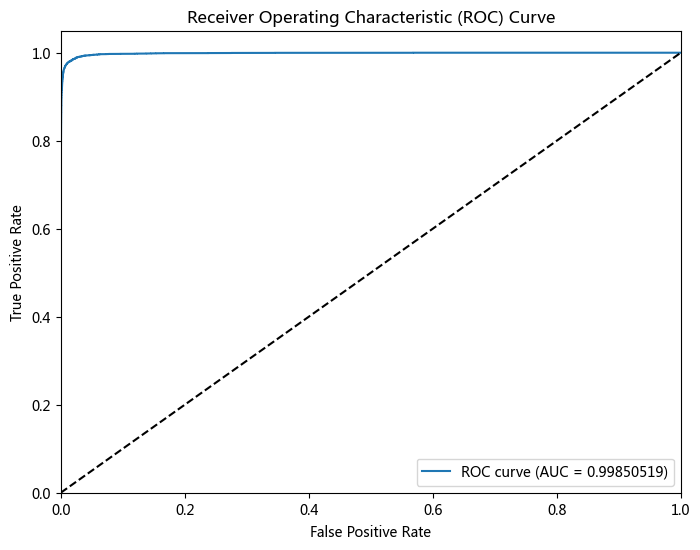

In [41]:
# 训练 pipeline
pipeline.fit(X_train, y_train)

# 对测试集的数据集进行预测
y_pred = pipeline.predict(X_test)

# 在测试集上进行评估
from sklearn import metrics
print("在测试集上的混淆矩阵：")
print(metrics.confusion_matrix(y_test, y_pred))
print("在测试集上的分类结果报告：")
print(metrics.classification_report(y_test, y_pred))
print("在测试集上的 f1-score ：")
print(metrics.f1_score(y_test, y_pred))

# 绘制 ROC 曲线
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 获取预测分数：如果模型有 predict_proba，则使用其第二列，否则使用 decision_function
if hasattr(pipeline, "predict_proba"):
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    print(y_scores)
else:
    y_scores = pipeline.decision_function(X_test)

# 计算 ROC 曲线数据
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# 绘制 ROC 曲线
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.8f})')
plt.plot([0, 1], [0, 1], 'k--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [4]:
# 在所有的样本上训练一次，充分利用已有的数据，提高模型的泛化能力
pipeline.fit(X, y)
# 保存训练的模型，请将模型保存在 results 目录下
import joblib
pipeline_path = 'results/pipeline.model'
joblib.dump(pipeline, pipeline_path)


['results/pipeline.model']